# Task 1 – Image Preprocessing for Handwritten Digit Recognition

This notebook presents the design and evaluation of image preprocessing techniques
for handwritten digit recognition. The goal of preprocessing is to enhance image
quality and normalize input data before segmentation and model training.

The MNIST dataset (loaded via PyTorch) is used as a reference dataset, and all
preprocessing pipelines are designed to be compatible with MNIST-style inputs.

In [1]:
import torch
from torchvision import datasets, transforms

# 1. Define Preprocessing (Normalize the data)
transform = transforms.Compose([
    transforms.ToTensor(), # Convert image to Tensor (C, H, W) and scale to [0, 1]
    transforms.Normalize((0.1307,), (0.3081,)) # Normalize using MNIST mean and std dev
])

# 2. Automatically load data
data_path = './COS30018-IntelSystem-Handwritten-Number-Recognition-System/data'  

train_dataset = datasets.MNIST(root=data_path, train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root=data_path, train=False, download=True, transform=transform)

# 3. Create DataLoaders (To feed into the model)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=1000, shuffle=False)

Quick check on the train and test set, labels and img shape

In [2]:
# Dataset sanity check
print("MNIST loaded successfully")
print("Number of training images:", len(train_dataset))
print("Number of test images:", len(test_dataset))

# Check one sample
sample_image, sample_label = train_dataset[0]
print("Sample image shape:", sample_image.shape)
print("Sample image min/max:", sample_image.min().item(), sample_image.max().item())
print("Sample label:", sample_label)

MNIST loaded successfully
Number of training images: 60000
Number of test images: 10000
Sample image shape: torch.Size([1, 28, 28])
Sample image min/max: -0.4242129623889923 2.821486711502075
Sample label: 5


Inspect raw MNIST images

Label: 5
Image shape: torch.Size([1, 28, 28])
Pixel range: -0.4242129623889923 2.821486711502075


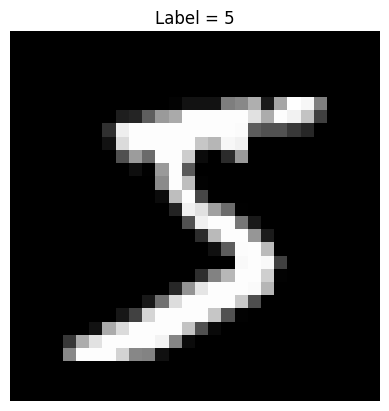

In [3]:
import matplotlib.pyplot as plt

# Get one sample from the dataset
image, label = train_dataset[0]

print("Label:", label)
print("Image shape:", image.shape)
print("Pixel range:", image.min().item(), image.max().item())

# Convert tensor to numpy for visualization
plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Label = {label}")
plt.axis("off")
plt.show()

## Preprocessing Pipeline A – Baseline

The baseline preprocessing pipeline applies minimal operations:
- Conversion to tensor format
- Normalization to the range [0, 1]

This pipeline serves as a reference to evaluate the effect of more advanced
preprocessing techniques.

In [4]:
def preprocess_baseline(pil_image):
    transform = transforms.ToTensor()
    return transform(pil_image)

## Preprocessing Pipeline B – Enhanced

The enhanced preprocessing pipeline is designed to reduce noise and improve
foreground–background separation. It includes:
- Noise reduction using median filtering
- Automatic thresholding
- Morphological operations to refine digit shapes

In [5]:
import cv2

def preprocess_enhanced(pil_image):
    img = np.array(pil_image)

    # Median blur for noise reduction
    img = cv2.medianBlur(img, 3)

    # Otsu thresholding
    _, img = cv2.threshold(
        img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # Morphological opening
    kernel = np.ones((2, 2), np.uint8)
    img = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel)

    # Convert to tensor and normalize
    img = torch.tensor(img, dtype=torch.float32) / 255.0
    return img.unsqueeze(0)

## Visual Comparison of Preprocessing Pipelines

The following figures compare the original image with the outputs of the
baseline and enhanced preprocessing pipelines.

In [8]:
image, label = train_dataset[0]

baseline_img = preprocess_baseline(raw_img)
enhanced_img = preprocess_enhanced(raw_img)

fig, axes = plt.subplots(1, 3, figsize=(9, 3))

axes[0].imshow(raw_img, cmap="gray")
axes[0].set_title("Raw Image")

axes[1].imshow(baseline_img.squeeze(), cmap="gray")
axes[1].set_title("Baseline")

axes[2].imshow(enhanced_img.squeeze(), cmap="gray")
axes[2].set_title("Enhanced")

for ax in axes:
    ax.axis("off")

plt.suptitle(f"Label: {label}")
plt.show()

TypeError: pic should be PIL Image or ndarray. Got <class 'torch.Tensor'>